ANALYZING DISEASE PREDICTIONS IN LLM RESPONSES

Parsing results file: full_results_20251214_143641.txt
Found 833 patient records

Analyzing disease predictions in LLM responses...

Creating visualizations...


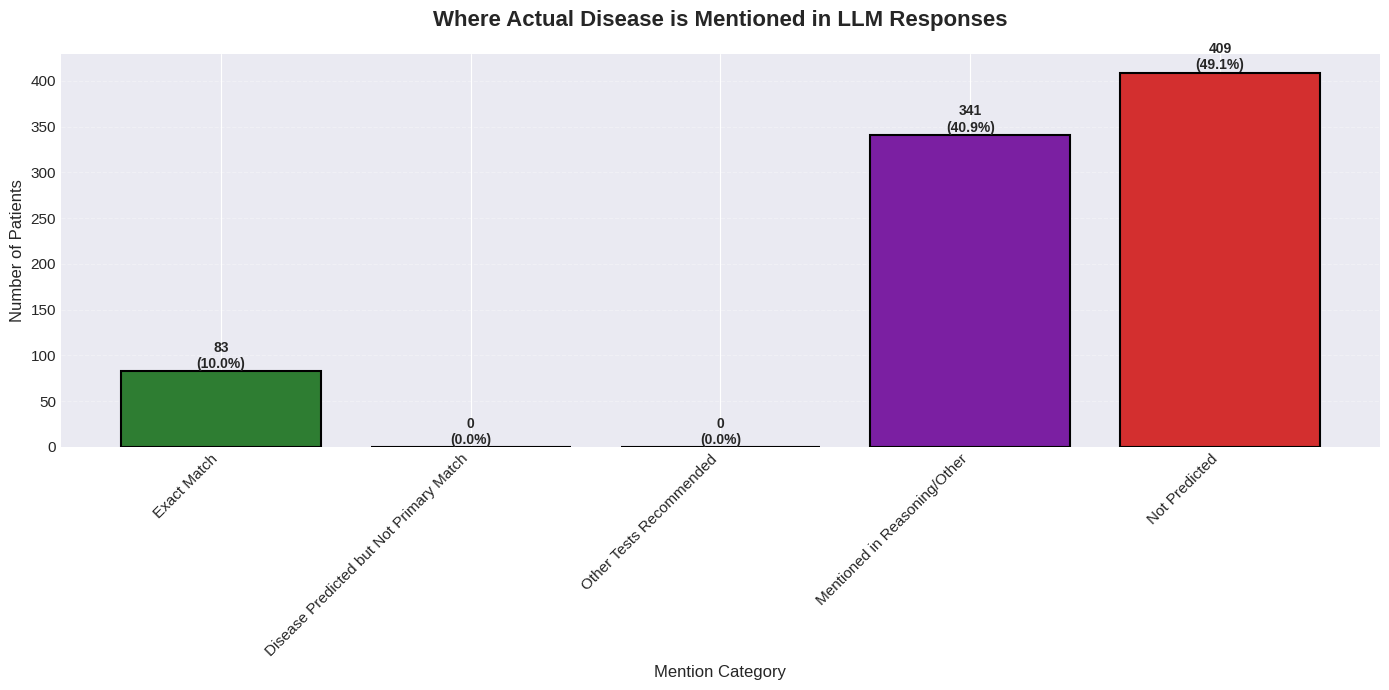

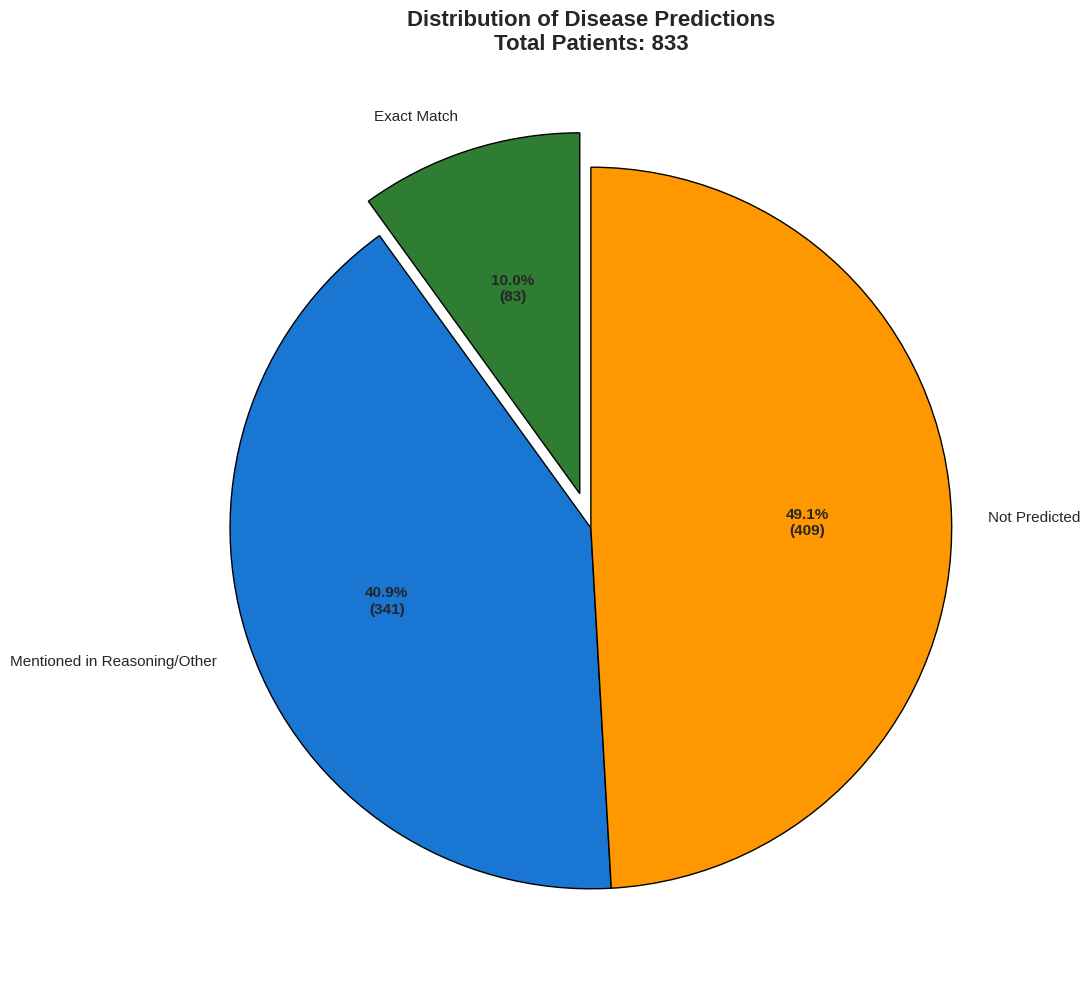

<Figure size 1600x900 with 0 Axes>

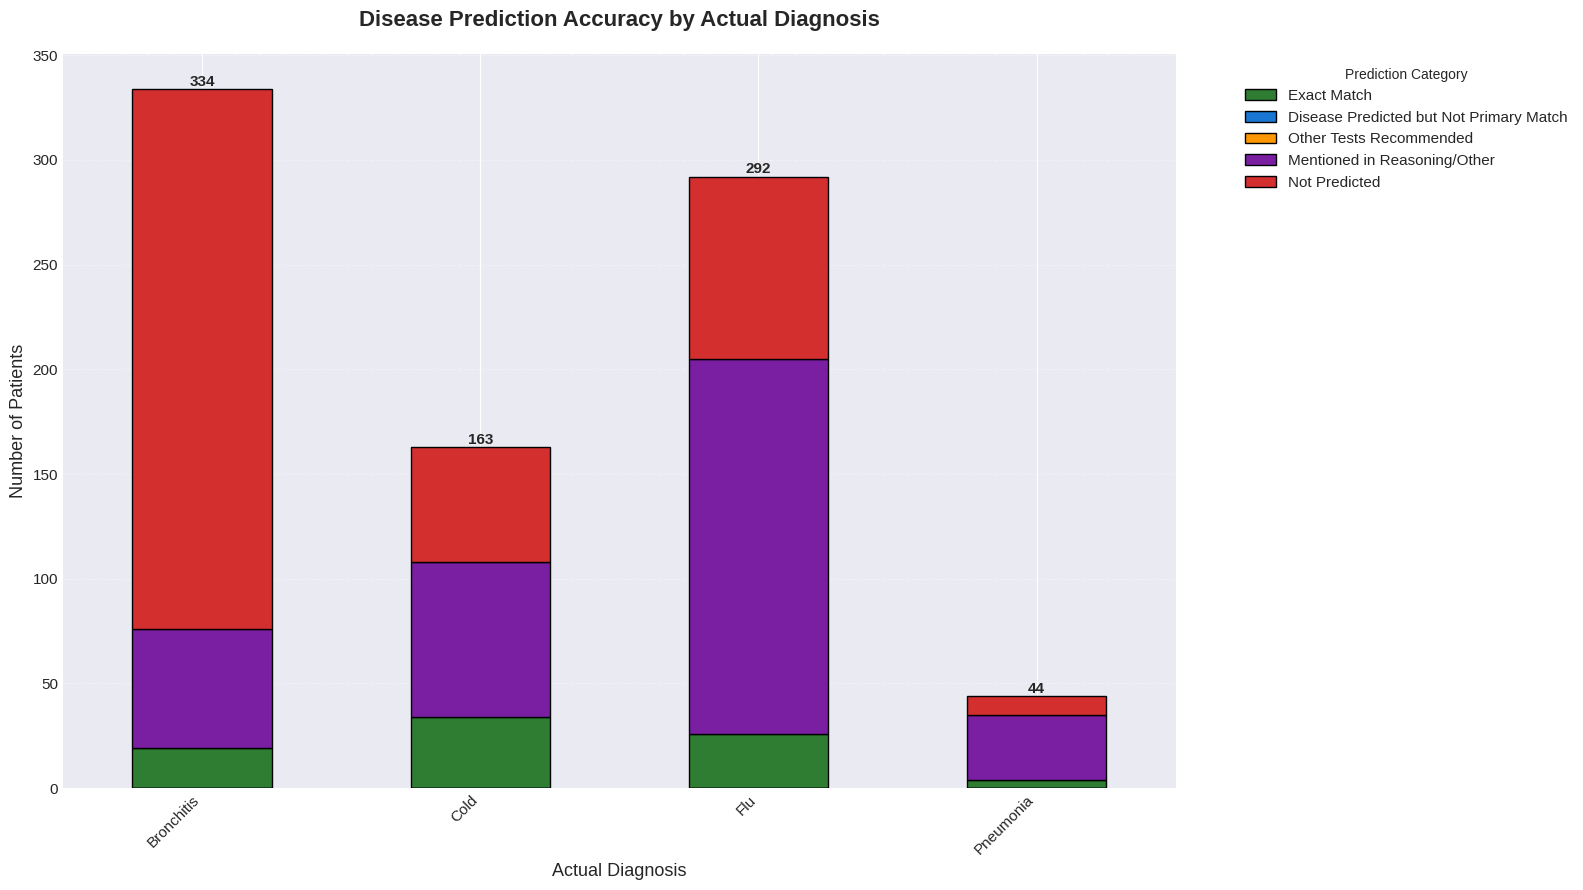

/tmp/ipykernel_5762/2600122442.py:311: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  percentage = heatmap_data[i]


<Figure size 1000x800 with 0 Axes>

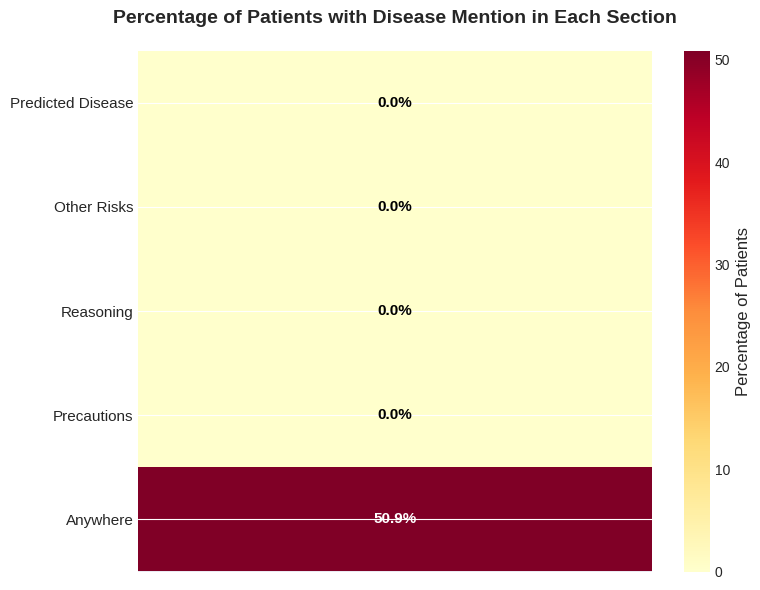

<Figure size 1200x600 with 0 Axes>

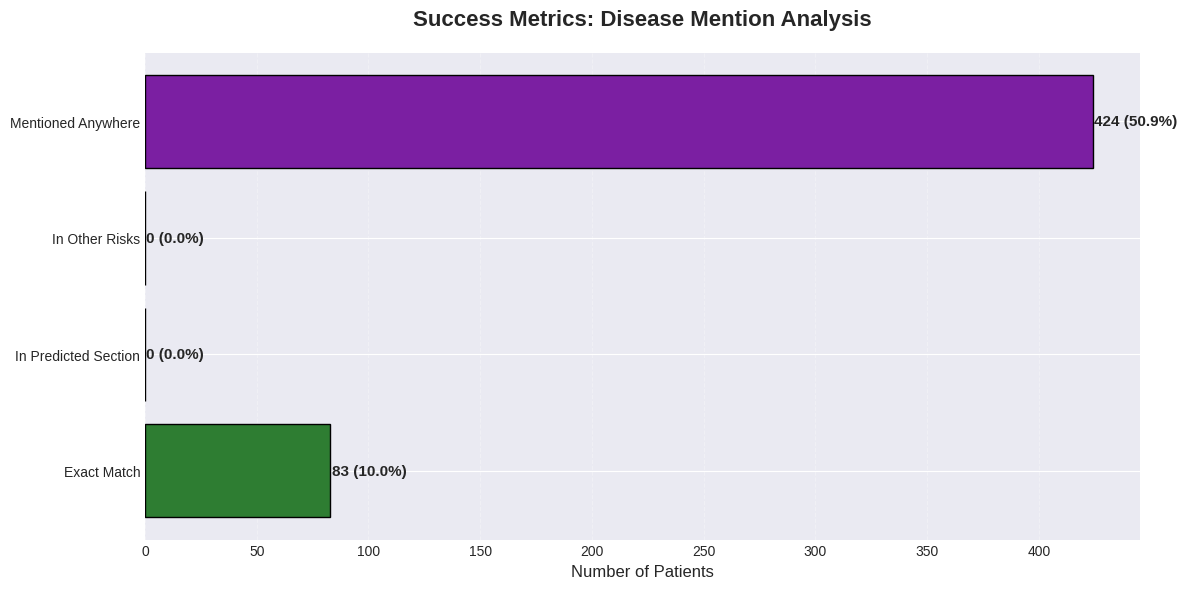


DETAILED ANALYSIS RESULTS

Total Patients Analyzed: 833

Prediction Categories:
  Exact Match                             : 83.0 patients (10.0%)
  Mentioned in Reasoning/Other            : 341.0 patients (40.9%)
  Not Predicted                           : 409.0 patients (49.1%)

Breakdown by Actual Diagnosis:

  Bronchitis:
    Total patients: 334
    Exact matches: 19 (5.7%)
    Mentioned anywhere: 76 (22.8%)
    Exact Match: 19 (5.7%)
    Mentioned in Reasoning/Other: 57 (17.1%)
    Not Predicted: 258 (77.2%)

  Cold:
    Total patients: 163
    Exact matches: 34 (20.9%)
    Mentioned anywhere: 108 (66.3%)
    Exact Match: 34 (20.9%)
    Mentioned in Reasoning/Other: 74 (45.4%)
    Not Predicted: 55 (33.7%)

  Flu:
    Total patients: 292
    Exact matches: 26 (8.9%)
    Mentioned anywhere: 205 (70.2%)
    Exact Match: 26 (8.9%)
    Mentioned in Reasoning/Other: 179 (61.3%)
    Not Predicted: 87 (29.8%)

  Pneumonia:
    Total patients: 44
    Exact matches: 4 (9.1%)
    Mentioned 

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np
import datetime

def parse_results_file(filename):
    """Parse the full results text file"""
    with open(filename, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Split by patient sections
    sections = content.split('\n' + '='*80 + '\n')
    
    results = []
    current_patient = {}
    
    for section in sections[2:]:  # Skip header and empty first section
        if not section.strip():
            continue
            
        lines = section.strip().split('\n')
        current_patient = {}
        
        for line in lines:
            if line.startswith('PATIENT ID:'):
                current_patient['patient_id'] = int(line.split(':')[1].strip())
            elif line.startswith('AGE/GENDER:'):
                age_gender = line.split(':')[1].strip()
                age = int(age_gender.split('years')[0].strip())
                gender = age_gender.split(',')[1].strip()
                current_patient['age'] = age
                current_patient['gender'] = gender
            elif line.startswith('ACTUAL DIAGNOSIS:'):
                current_patient['actual_diagnosis'] = line.split(':')[1].strip()
            elif line.startswith('PREDICTED DISEASE:'):
                current_patient['predicted_disease'] = line.split(':')[1].strip()
            elif line.startswith('MATCH:'):
                match_symbol = line.split(':')[1].strip()
                current_patient['match'] = match_symbol == '✓'
        
        # Extract LLM response section
        llm_start = False
        llm_response = []
        for line in lines:
            if line.startswith('LLM RESPONSE:'):
                llm_start = True
                continue
            elif llm_start and line.startswith('EXTRACTED SECTIONS:'):
                break
            elif llm_start and line:
                llm_response.append(line)
        
        if llm_response:
            # Remove the separator line if present
            llm_response_clean = '\n'.join(llm_response).replace('-' * 40, '').strip()
            current_patient['llm_response'] = llm_response_clean
        
        if current_patient:
            results.append(current_patient)
    
    return results

def check_disease_mentions(actual_disease, llm_response):
    """Check where the actual disease is mentioned in the LLM response"""
    
    # Normalize disease names for comparison
    def normalize_disease_name(name):
        name_lower = name.lower().strip()
        
        # Common variations and synonyms
        disease_mappings = {
            'flu': ['influenza', 'flu', 'viral influenza'],
            'cold': ['common cold', 'cold', 'upper respiratory infection', 'uri'],
            'pneumonia': ['pneumonia', 'community-acquired pneumonia'],
            'bronchitis': ['bronchitis', 'acute bronchitis'],
            'mononucleosis': ['mono', 'mononucleosis', 'ebv', 'epstein-barr'],
            'strep throat': ['strep', 'streptococcal', 'pharyngitis']
        }
        
        # Get all variations for this disease
        variations = [name_lower]
        for base_disease, var_list in disease_mappings.items():
            if base_disease in name_lower:
                variations.extend(var_list)
        
        return variations
    
    # Get disease variations
    disease_variations = normalize_disease_name(actual_disease)
    
    # Check in different sections
    mentions = {
        'in_predicted': False,
        'in_other_risks': False,
        'in_reasoning': False,
        'in_precautions': False,
        'anywhere': False
    }
    
    response_lower = llm_response.lower()
    
    # Check if mentioned anywhere
    for variation in disease_variations:
        if variation in response_lower:
            mentions['anywhere'] = True
            break
    
    # Check specific sections
    sections = {
        'predicted': r'\*\*Most (?:Suspected|Suspicious) Disease:\*\*\s*([^*]+?)(?=\n\s*\*\*|\n\s*$)',
        'other_risks': r'\*\*Other (?:Significant Risks|Possible Diseases):\*\*\s*([^*]+?)(?=\n\s*\*\*|\n\s*$)',
        'reasoning': r'\*\*Diagnostic (?:Reasoning|Reasons):\*\*\s*([^*]+?)(?=\n\s*\*\*|\n\s*$)',
        'precautions': r'\*\*Precautions:\*\*\s*([^*]+?)(?=\n\s*\*\*|\n\s*$|\Z)'
    }
    
    for section_name, pattern in sections.items():
        match = re.search(pattern, response_lower, re.DOTALL)
        if match:
            section_text = match.group(1).lower()
            for variation in disease_variations:
                if variation in section_text:
                    if section_name == 'predicted':
                        mentions['in_predicted'] = True
                    elif section_name == 'other_risks':
                        mentions['in_other_risks'] = True
                    elif section_name == 'reasoning':
                        mentions['in_reasoning'] = True
                    elif section_name == 'precautions':
                        mentions['in_precautions'] = True
    
    return mentions

def analyze_results(results):
    """Analyze where actual diseases are mentioned in LLM responses"""
    
    analysis = []
    
    for result in results:
        if 'llm_response' not in result or 'actual_diagnosis' not in result:
            continue
        
        patient_info = {
            'patient_id': result['patient_id'],
            'actual_diagnosis': result['actual_diagnosis'],
            'predicted_disease': result.get('predicted_disease', 'Unknown'),
            'exact_match': result.get('match', False)
        }
        
        # Check disease mentions
        mentions = check_disease_mentions(
            result['actual_diagnosis'], 
            result['llm_response']
        )
        
        patient_info.update(mentions)
        
        # Determine mention category with new labels
        if patient_info['exact_match']:
            patient_info['mention_category'] = 'Exact Match'
        elif patient_info['in_predicted']:
            patient_info['mention_category'] = 'Disease Predicted but Not Primary Match'
        elif patient_info['in_other_risks']:
            patient_info['mention_category'] = 'Other Tests Recommended'
        elif patient_info['anywhere']:
            patient_info['mention_category'] = 'Mentioned in Reasoning/Other'
        else:
            patient_info['mention_category'] = 'Not Predicted'
        
        analysis.append(patient_info)
    
    return pd.DataFrame(analysis)

def create_visualizations(df, filename_prefix):
    """Create visualizations for the analysis"""
    
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # 1. Overall mention categories with new labels
    plt.figure(figsize=(14, 7))
    
    # Count mentions by category
    mention_counts = df['mention_category'].value_counts()
    
    # Reorder categories for better visualization
    category_order = [
        'Exact Match',
        'Disease Predicted but Not Primary Match',
        'Other Tests Recommended',
        'Mentioned in Reasoning/Other',
        'Not Predicted'
    ]
    
    # Filter and order categories
    mention_counts = mention_counts.reindex(category_order).fillna(0)
    
    # Create bar chart with better colors
    colors = ['#2E7D32', '#1976D2', '#FF9800', '#7B1FA2', '#D32F2F']
    bars = plt.bar(mention_counts.index, mention_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    
    plt.title('Where Actual Disease is Mentioned in LLM Responses', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Mention Category', fontsize=12)
    plt.ylabel('Number of Patients', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    
    # Add count and percentage labels on bars
    total = len(df)
    for bar in bars:
        height = bar.get_height()
        percentage = (height / total) * 100
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add grid
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{filename_prefix}_mention_categories.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Pie chart of mention distribution
    plt.figure(figsize=(12, 10))
    
    # Filter out zero values
    pie_data = mention_counts[mention_counts > 0]
    
    # Create explode for emphasis on Exact Match
    explode = [0.1 if cat == 'Exact Match' else 0 for cat in pie_data.index]
    
    # Colors for pie chart
    pie_colors = colors[:len(pie_data)]
    
    # Create pie chart
    wedges, texts, autotexts = plt.pie(
        pie_data.values, 
        labels=pie_data.index, 
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total)})',
        startangle=90,
        explode=explode,
        colors=pie_colors,
        textprops={'fontsize': 11},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )
    
    plt.title('Distribution of Disease Predictions\nTotal Patients: {}'.format(total), 
              fontsize=16, fontweight='bold', pad=20)
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.savefig(f'{filename_prefix}_mention_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Breakdown by actual diagnosis
    plt.figure(figsize=(16, 9))
    
    # Create pivot table
    pivot_data = pd.crosstab(df['actual_diagnosis'], df['mention_category'])
    
    # Reorder columns
    pivot_data = pivot_data.reindex(columns=category_order, fill_value=0)
    
    # Plot stacked bar chart
    ax = pivot_data.plot(kind='bar', stacked=True, figsize=(16, 9), 
                        color=colors, edgecolor='black', linewidth=1)
    
    plt.title('Disease Prediction Accuracy by Actual Diagnosis', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Actual Diagnosis', fontsize=13)
    plt.ylabel('Number of Patients', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.legend(title='Prediction Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    
    # Add total counts on top of each bar
    for i, (idx, row) in enumerate(pivot_data.iterrows()):
        total_diagnosis = row.sum()
        plt.text(i, total_diagnosis + 0.1, str(total_diagnosis), 
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Add grid
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{filename_prefix}_by_diagnosis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Heatmap of mention locations (fixed formatting)
    plt.figure(figsize=(10, 8))
    
    # Prepare data for heatmap
    heatmap_data = df[['in_predicted', 'in_other_risks', 'in_reasoning', 'in_precautions', 'anywhere']].mean() * 100
    
    # Create heatmap with correct formatting
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Reshape data for heatmap
    heatmap_values = heatmap_data.values.reshape(-1, 1)
    
    # Create heatmap
    im = ax.imshow(heatmap_values, cmap='YlOrRd', aspect='auto')
    
    # Add annotations
    for i in range(len(heatmap_data)):
        percentage = heatmap_data[i]
        text = f'{percentage:.1f}%'
        ax.text(0, i, text, ha='center', va='center', 
                color='white' if percentage > 50 else 'black',
                fontweight='bold', fontsize=11)
    
    # Set labels
    ax.set_yticks(range(len(heatmap_data)))
    ax.set_yticklabels(['Predicted Disease', 'Other Risks', 'Reasoning', 'Precautions', 'Anywhere'],
                      fontsize=11)
    ax.set_xticks([])
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Percentage of Patients', fontsize=12)
    
    plt.title('Percentage of Patients with Disease Mention in Each Section', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(f'{filename_prefix}_mention_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. Success metrics visualization
    plt.figure(figsize=(12, 6))
    
    # Calculate success metrics
    exact_matches = df['exact_match'].sum()
    in_predicted = df['in_predicted'].sum()
    in_other_risks = df['in_other_risks'].sum()
    anywhere = df['anywhere'].sum()
    
    metrics = {
        'Exact Match': exact_matches,
        'In Predicted Section': in_predicted,
        'In Other Risks': in_other_risks,
        'Mentioned Anywhere': anywhere
    }
    
    # Create horizontal bar chart
    categories = list(metrics.keys())
    values = list(metrics.values())
    percentages = [(v / total) * 100 for v in values]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(categories, values, color=['#2E7D32', '#1976D2', '#FF9800', '#7B1FA2'], 
                   edgecolor='black', linewidth=1)
    
    # Add value labels
    for i, (bar, value, pct) in enumerate(zip(bars, values, percentages)):
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
               f'{value} ({pct:.1f}%)', va='center', fontweight='bold', fontsize=11)
    
    ax.set_xlabel('Number of Patients', fontsize=12)
    ax.set_title('Success Metrics: Disease Mention Analysis', fontsize=16, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{filename_prefix}_success_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 6. Detailed statistics table
    print("\n" + "="*80)
    print("DETAILED ANALYSIS RESULTS")
    print("="*80)
    
    print(f"\nTotal Patients Analyzed: {len(df)}")
    print("\nPrediction Categories:")
    for category, count in mention_counts.items():
        if count > 0:
            percentage = (count / total) * 100
            print(f"  {category:<40}: {count:>3} patients ({percentage:.1f}%)")
    
    print("\nBreakdown by Actual Diagnosis:")
    for diagnosis in sorted(df['actual_diagnosis'].unique()):
        subset = df[df['actual_diagnosis'] == diagnosis]
        exact_matches = subset['exact_match'].sum()
        mentioned = subset['anywhere'].sum()
        print(f"\n  {diagnosis}:")
        print(f"    Total patients: {len(subset)}")
        print(f"    Exact matches: {exact_matches} ({exact_matches/len(subset)*100:.1f}%)")
        print(f"    Mentioned anywhere: {mentioned} ({mentioned/len(subset)*100:.1f}%)")
        
        # Show category distribution for this diagnosis
        for category in category_order:
            count = (subset['mention_category'] == category).sum()
            if count > 0:
                percentage = (count / len(subset)) * 100
                print(f"    {category}: {count} ({percentage:.1f}%)")
    
    # Save detailed statistics to file
    stats_file = f'{filename_prefix}_detailed_stats.txt'
    with open(stats_file, 'w', encoding='utf-8') as f:
        f.write("DETAILED ANALYSIS OF DISEASE PREDICTIONS IN LLM RESPONSES\n")
        f.write("="*70 + "\n\n")
        f.write(f"Analysis Date: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Total Patients Analyzed: {len(df)}\n\n")
        
        f.write("OVERALL PREDICTION CATEGORIES:\n")
        f.write("-"*50 + "\n")
        for category, count in mention_counts.items():
            if count > 0:
                percentage = (count / total) * 100
                f.write(f"{category:<45}: {count:>3} patients ({percentage:.1f}%)\n")
        
        f.write("\n\nBREAKDOWN BY ACTUAL DIAGNOSIS:\n")
        f.write("-"*50 + "\n")
        for diagnosis in sorted(df['actual_diagnosis'].unique()):
            subset = df[df['actual_diagnosis'] == diagnosis]
            exact_matches = subset['exact_match'].sum()
            mentioned = subset['anywhere'].sum()
            
            f.write(f"\n{diagnosis}:\n")
            f.write(f"  Total patients: {len(subset)}\n")
            f.write(f"  Exact matches: {exact_matches} ({exact_matches/len(subset)*100:.1f}%)\n")
            f.write(f"  Mentioned anywhere: {mentioned} ({mentioned/len(subset)*100:.1f}%)\n")
            
            f.write("  Prediction categories:\n")
            for category in category_order:
                count = (subset['mention_category'] == category).sum()
                if count > 0:
                    percentage = (count / len(subset)) * 100
                    f.write(f"    {category}: {count} ({percentage:.1f}%)\n")
    
    print(f"\nDetailed statistics saved to: {stats_file}")

def main():
    """Main analysis function"""
    
    # Input file
    input_file = "full_results_20251214_143641.txt"
    
    print("="*80)
    print("ANALYZING DISEASE PREDICTIONS IN LLM RESPONSES")
    print("="*80)
    
    # Parse the results file
    print(f"\nParsing results file: {input_file}")
    results = parse_results_file(input_file)
    print(f"Found {len(results)} patient records")
    
    if not results:
        print("No results found!")
        return
    
    # Analyze where diseases are mentioned
    print("\nAnalyzing disease predictions in LLM responses...")
    df = analyze_results(results)
    
    # Generate filename prefix
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_prefix = f"disease_prediction_analysis_{timestamp}"
    
    # Create visualizations
    print("\nCreating visualizations...")
    create_visualizations(df, filename_prefix)
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    
    # Show summary
    total_patients = len(df)
    exact_matches = df['exact_match'].sum()
    in_predicted = df['in_predicted'].sum()
    in_other_risks = df['in_other_risks'].sum()
    mentioned_anywhere = df['anywhere'].sum()
    
    print(f"\nSUMMARY:")
    print(f"Total patients analyzed: {total_patients}")
    print(f"Exact matches: {exact_matches} ({exact_matches/total_patients*100:.1f}%)")
    print(f"Disease in predicted section: {in_predicted} ({in_predicted/total_patients*100:.1f}%)")
    print(f"Disease in other risks: {in_other_risks} ({in_other_risks/total_patients*100:.1f}%)")
    print(f"Disease mentioned anywhere: {mentioned_anywhere} ({mentioned_anywhere/total_patients*100:.1f}%)")
    
    # Calculate overall success rate (exact match or mentioned in predicted)
    overall_success = exact_matches + in_predicted
    print(f"\nOverall Success (Exact or in Predicted): {overall_success} ({overall_success/total_patients*100:.1f}%)")
    
    # Files created
    print(f"\nFiles created:")
    print(f"  - {filename_prefix}_mention_categories.png (bar chart)")
    print(f"  - {filename_prefix}_mention_distribution.png (pie chart)")
    print(f"  - {filename_prefix}_by_diagnosis.png (diagnosis breakdown)")
    print(f"  - {filename_prefix}_mention_heatmap.png (heatmap)")
    print(f"  - {filename_prefix}_success_metrics.png (success metrics)")
    print(f"  - {filename_prefix}_detailed_stats.txt (detailed statistics)")

if __name__ == "__main__":
    main()